In [71]:
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
ds = pd.read_csv("https://raw.githubusercontent.com/Karti02/Iris-ml/refs/heads/main/IRIS.csv")
print(ds.head(10))
ds.shape

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
6           4.6          3.4           1.4          0.3  Iris-setosa
7           5.0          3.4           1.5          0.2  Iris-setosa
8           4.4          2.9           1.4          0.2  Iris-setosa
9           4.9          3.1           1.5          0.1  Iris-setosa


(150, 5)

# Data cleaning

In [73]:
ds.drop_duplicates().count()

,0
sepal_length,147
sepal_width,147
petal_length,147
petal_width,147
species,147


In [74]:
ds.isna().count()

,0
sepal_length,150
sepal_width,150
petal_length,150
petal_width,150
species,150


# Segregation

In [75]:
ds.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [76]:
x = ds.loc[:,['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
print(x)
y = ds.loc[:,['species']]                                                                       # split
print(y)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
            species
0       Iris-setosa
1       Iris-setosa
2       Iris-setosa
3       Iris-setosa
4       Iris-setosa
..              ...
145  Iris-virginica
146  Iris-virginica
147  Iris-virginica
148  Iris-virginica
149  Iris-virginica

[150 rows x 1 columns]


In [77]:
print(ds.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


# Test & train

In [78]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state=42,stratify=y)

In [79]:
print(ds.head(5))
ds.shape

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


(150, 5)

Plotting

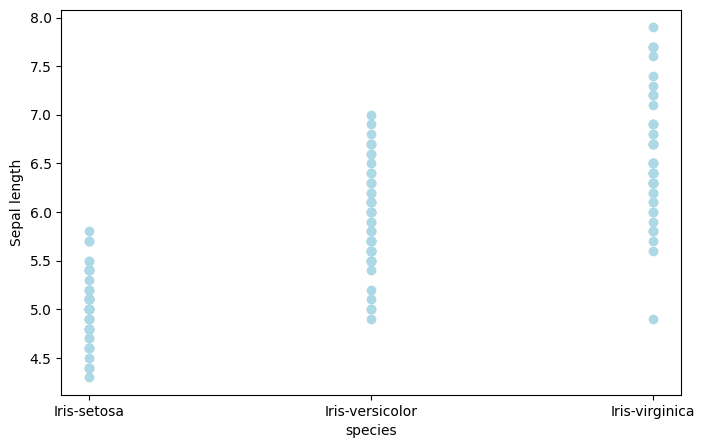

In [80]:
import matplotlib.pyplot as plt
plt.figure(figsize =(8,5))
plt.scatter(x=ds['species'],y=ds['sepal_length'],color='lightblue')
plt.xlabel('species')
plt.ylabel('Sepal length')
plt.show()

In [ ]:
# Scaliing and Training

In [81]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [83]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

Determining Acurracy through different Methods.

In [84]:
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
print('Acurracy score is :',accuracy_score(y_test,y_pred)*100)

Acurracy score is : 92.10526315789474


In [85]:
from sklearn.metrics import classification_report
print('report',classification_report(y_test,y_pred))

report                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.86      0.92      0.89        13
 Iris-virginica       0.92      0.85      0.88        13

       accuracy                           0.92        38
      macro avg       0.92      0.92      0.92        38
   weighted avg       0.92      0.92      0.92        38



In [86]:
from sklearn.metrics import confusion_matrix
print('confusion_matrix',confusion_matrix(y_test,y_pred))

confusion_matrix [[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]


Prediction

In [87]:
features =[[6.7,3.5,5.5,2.5]]
scaled = sc.transform(features)
pred = model.predict(scaled)
print(pred)

['Iris-virginica']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [88]:
sl = float(input("Enter sepal length :"))
sw = float(input("Enter sepal width :"))
pl = float(input("Enter petal length :"))
pw = float(input("Enter petal width :"))
features = [[sl,sw,pl,pw]]
scaled = sc.transform(features)
predic = model.predict(scaled)
print(predic[0])

Enter sepal length :1.2
Enter sepal width :1.2
Enter petal length :9
Enter petal width :1.5
Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Downloading model and scaler

In [89]:
import joblib
joblib.dump(model,'model.joblib')

['model.joblib']

In [96]:
joblib.dump(sc,'scaler.joblib')

['scaler.joblib']

In [97]:
loadm = joblib.load('model.joblib')

In [98]:
loads = joblib.load('scaler.joblib')